Evaluate the presence of factual claim-making in SemEval articles and the relationship between propaganda and claim-making.

In [1]:
import pandas as pd
import spacy
from scipy import stats
import gc
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

In [2]:
#Import functions for claim extraction
BASE_DIR = Path("../").resolve()
utils_path = str(BASE_DIR / "create-model")
if utils_path not in sys.path:
    sys.path.append(utils_path)
from claim_utils import lightweight_claimify

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/frankiepike/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/frankiepike/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
04/07/2026 11:29:05 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/07/2026 11:29:05 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
04/07/2026 11:29:05 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/07/2026 11:29:05 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
04/07/2026 11:29:05 - INFO - 	 HTTP Request: H

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

FCorefModel LOAD REPORT from: biu-nlp/f-coref
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
04/07/2026 11:29:06 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/main "HTTP/1.1 200 OK"
04/07/2026 11:29:06 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/discussions?p=0 "HTTP/1.1 200 OK"
04/07/2026 11:29:06 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
04/07/2026 11:29:06 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
04/07/2026 11:29:06 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/mo

Loading weights:   0%|          | 0/283 [00:00<?, ?it/s]

04/07/2026 11:29:07 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/valhalla/distilbart-mnli-12-3/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
04/07/2026 11:29:07 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/valhalla/distilbart-mnli-12-3/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


In [3]:
#Load cleaned SemEval datasets
DATA_PATH = BASE_DIR / "data" / "interim" / "semeval_task2_tc_merged.csv"
df_merged = pd.read_csv(DATA_PATH)

#Define the persistent save path
processed_data_path = BASE_DIR / "data" / "interim" / "propaganda_vs_fact_stats.csv"

In [4]:
#Load lightweight spaCy model
nlp = spacy.load("en_core_web_sm")

In [5]:
#Group gold spans and unique articles
gold_spans_dict = df_merged.groupby('article_id').apply(
    lambda x: list(zip(x['start_char'].astype(int), x['end_char'].astype(int), x['technique']))
).to_dict()

unique_articles = df_merged[['article_id', 'text_content']].drop_duplicates('article_id')

In [14]:
#Analysis logic
def has_overlap(sent_start, sent_end, spans):
    for span_start, span_end, _ in spans:
        if span_start < sent_end and span_end > sent_start:
            return True
    return False

In [7]:
def get_propaganda_data(sent_start, sent_end, article_spans):
    found_techs = []
    for s_start, s_end, tech in article_spans:
        if s_start < sent_end and s_end > sent_start:
            found_techs.append(tech)
    return len(found_techs) > 0, list(set(found_techs))

In [8]:
if processed_data_path.exists():
    df_existing = pd.read_csv(processed_data_path)
    processed_ids = set(df_existing['article_id'].unique())
    print(f"Resuming: {len(processed_ids)} articles already completed.")
    gc.collect()
else:
    processed_ids = set()

Resuming: 357 articles already completed.


In [9]:
remaining_articles = unique_articles[~unique_articles['article_id'].isin(processed_ids)]
print(f"""{len(remaining_articles)} articles still need to be processed""")

for i, (_, row) in enumerate(tqdm(remaining_articles.iterrows(), total=len(remaining_articles))):
    aid = row['article_id']
    text = str(row['text_content'])
    spans = gold_spans_dict.get(aid, [])

    doc = nlp(text)
    total_sents = 0
    art_counts = {"prop_only": 0, "fact_only": 0, "both": 0, "neither": 0}

    #List to store techniques specifically used in 'both' sentences
    techniques_in_both = []

    for sent in doc.sents:
        total_sents += 1

        is_prop, techs_found = get_propaganda_data(sent.start_char, sent.end_char, spans)

        extracted_claims = lightweight_claimify(sent.text)
        is_fact = len(extracted_claims) > 0

        if is_prop and is_fact:
            art_counts["both"] += 1
            techniques_in_both.extend(techs_found)
        elif is_prop:
            art_counts["prop_only"] += 1
        elif is_fact:
            art_counts["fact_only"] += 1
        else:
            art_counts["neither"] += 1

    if total_sents > 0:
        #Create a unique, comma-separated list of techniques used in 'both' instances
        both_tech_summary = ",".join(sorted(set(techniques_in_both)))

        new_entry = pd.DataFrame([{
            "article_id": aid,
            "total_sentences": total_sents,
            "count_prop_only": art_counts["prop_only"],
            "count_fact_only": art_counts["fact_only"],
            "count_both": art_counts["both"],
            "count_neither": art_counts["neither"],
            "techniques_in_both": both_tech_summary,
            "prop_density": ((art_counts["prop_only"] + art_counts["both"]) / total_sents) * 100,
            "fact_density": ((art_counts["fact_only"] + art_counts["both"]) / total_sents) * 100
        }])

        new_entry.to_csv(processed_data_path, mode='a', index=False, header=not processed_data_path.exists())

    #Memory Cleanup
    if (i + 1) % 2 == 0:
        del doc
        gc.collect()

0 articles still need to be processed


0it [00:00, ?it/s]


In [10]:
#Reload full data
df_stats = pd.read_csv(processed_data_path)

counts = {
    "Propaganda Only": df_stats['count_prop_only'].sum(),
    "Fact Only": df_stats['count_fact_only'].sum(),
    "Both": df_stats['count_both'].sum(),
    "Neither": df_stats['count_neither'].sum()
}

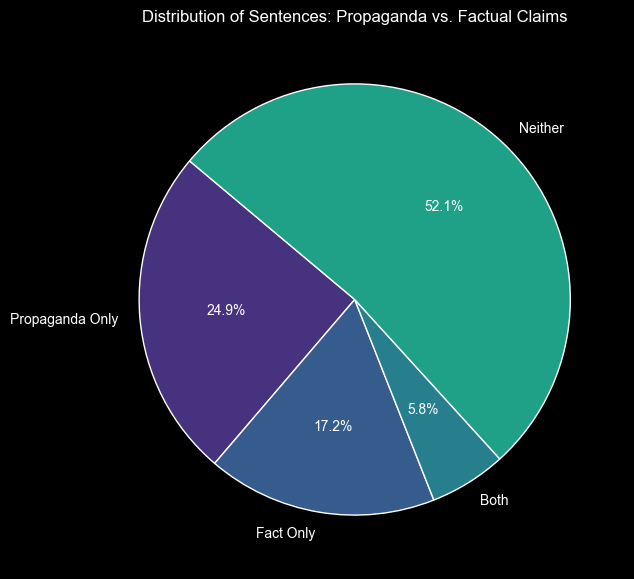

In [11]:
#Percentage Breakdown (The Intersections)
plt.figure(figsize=(10, 7))
plt.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis"))
plt.title("Distribution of Sentences: Propaganda vs. Factual Claims")
plt.show()

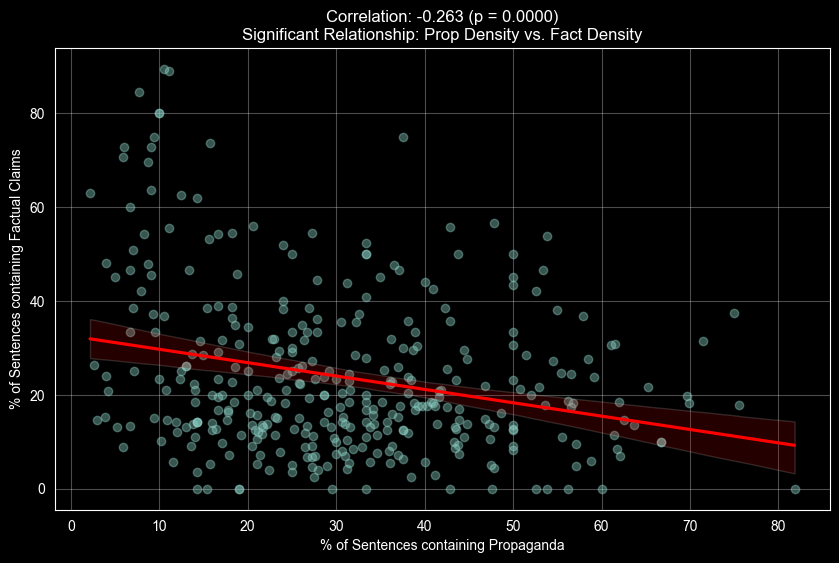

Correlation Coefficient (r): -0.2632
P-value: 4.5367e-07


In [12]:
#Calculate Pearson correlation and p-value
r, p_value = stats.pearsonr(df_stats['prop_density'], df_stats['fact_density'])

plt.figure(figsize=(10, 6))
sns.regplot(data=df_stats, x='prop_density', y='fact_density',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})

#Dynamic title showing significance
significance = "Significant" if p_value < 0.05 else "Not Significant"
plt.title(f"Correlation: {r:.3f} (p = {p_value:.4f})\n{significance} Relationship: Propaganda Density vs. Fact Density")

plt.xlabel("% of Sentences containing Propaganda")
plt.ylabel("% of Sentences containing Factual Claims")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correlation Coefficient (r): {r:.4f}")
print(f"P-value: {p_value:.4e}")

In [15]:
#Get random sample of weaponized facts
sample_count = 0
for _, row in unique_articles.sample(20).iterrows():
    if sample_count >= 5: break

    doc = nlp(str(row['text_content']))
    spans = gold_spans_dict.get(row['article_id'], [])

    for sent in doc.sents:
        if has_overlap(sent.start_char, sent.end_char, spans):
            claims = lightweight_claimify(sent.text)
            if len(claims) > 0:
                print(f"Weaponized Fact: {sent.text[:150]}...")
                sample_count += 1
                if sample_count >= 5: break

04/07/2026 11:38:01 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

04/07/2026 11:38:01 - INFO - 	 ***** Running Inference on 1 texts *****


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

04/07/2026 11:38:02 - INFO - 	 Tokenize 1 inputs...


...

04/07/2026 11:38:16 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

04/07/2026 11:38:16 - INFO - 	 ***** Running Inference on 1 texts *****


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

FOUND BOTH: The report calls the Holocaust “the biggest lie ever foisted upon humanity” and was produced by a media outlet which describes Hitler as “the greatest...
